In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [ ]:
!ls /content/drive/MyDrive



'100002850583622 (1).gdoc'
 100002850583622.gdoc
'Abhay_Singh_Mnnit (1).pdf'
 Abhay_Singh_Mnnit.pdf
'AbhaySinghResume (4) (1).pdf'
'AbhaySinghResume (4) (2).pdf'
'AbhaySinghResume (4) (3).pdf'
'AbhaySinghResume (4) (4).pdf'
'AbhaySinghResume (4).pdf'
'Advanced CS Study Material Request.gdoc'
'A_Hybrid_GA_ACO_and_NSGA_II_Framework_for_Dynamic_Influence_Maximization (3).pdf'
'A_Hybrid_GA_ACO_and_NSGA_II_Framework_for_Dynamic_Influence_Maximization (4) (1).pdf'
'based on these research paper give me novel thisi....gdoc'
 Classroom
 Codes
'Colab Notebooks'
 CoMoFoD
'Copy of COVID-19 Vaccine Tracker for India.gsheet'
'CS24S65024039_AdmitCard (1).pdf'
'DA24S15024060_AdmitCard (1).pdf'
'Digital img processing - LAB MANUAL DIGITAL IMAGE PROCESSING (CS-325) 2022- DEPARTMENT OF COMPUTER - Studocu'
 DinoV3new40.ipynb
'DINOv3 Preprocessing and Class Imbalance.gdoc'
'distribdystems book.pdf'
 Gb
'Getting started.pdf'
'G.Shanker Rao.gdoc'
 HostelPaymentReceipt.pdf
'ICM_GA_ACO (1).pdf'
'Image Forgery

In [ ]:
# point to your dataset folder
SRC_ROOT = "/content/drive/MyDrive/CoMoFoD"

# save processed dataset & CSVs back to Drive (safe from Colab resets)
OUT_ROOT = "/content/drive/MyDrive/CMFD_processed"


In [ ]:
# Step 1: Dataset loading & preprocessing for CoMoFoD (Colab-ready)

import os, glob
from pathlib import Path
from tqdm import tqdm
import cv2
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split

# -------- USER CONFIG --------
SRC_ROOT = "/content/drive/MyDrive/CoMoFoD"   # your dataset folder
OUT_ROOT = "/content/drive/MyDrive/CMFD_processed"
IMG_SIZE = (256, 256)   # resize target
TO_GRAY = False         # keep RGB (DINOv3 needs RGB)
# -----------------------------

os.makedirs(OUT_ROOT, exist_ok=True)
OUT_IM_DIR = os.path.join(OUT_ROOT, "images")
OUT_MK_DIR = os.path.join(OUT_ROOT, "masks")
os.makedirs(OUT_IM_DIR, exist_ok=True)
os.makedirs(OUT_MK_DIR, exist_ok=True)

def is_image(fname):
    return Path(fname).suffix.lower() in [".png", ".jpg", ".jpeg", ".bmp", ".tif"]

# collect all images in CoMoFoD
all_files = glob.glob(os.path.join(SRC_ROOT, "**", "*.*"), recursive=True)
all_images = [f for f in all_files if is_image(f)]

print(f"Total images found: {len(all_images)}")

manifest = []
for img_path in tqdm(all_images, desc="Processing"):
    fname = Path(img_path).stem

    # Skip colored masks (_M)
    if fname.endswith("_M"):
        continue

    # Identify type
    if "_O" in fname:   # original image
        label = 0
        mask_name = fname.replace("_O", "_B") + Path(img_path).suffix
    elif "_F" in fname: # forged image (with or without postprocessing)
        label = 1
        if "_B" in fname:
            # it's actually a binary mask, skip as image
            continue
        mask_name = fname.replace("_F", "_B")
        if "_" in fname:  # handle postprocessed ones like _F_JC1
            mask_name = fname.split("_F")[0] + "_B" + Path(img_path).suffix
    else:
        continue  # ignore unrelated files

    # locate mask
    mask_path = os.path.join(Path(img_path).parent, mask_name)
    if not os.path.exists(mask_path):
        continue  # skip if no mask

    # read and preprocess image
    im = cv2.imread(img_path, cv2.IMREAD_COLOR)
    if im is None:
        continue
    if TO_GRAY:
        im = cv2.cvtColor(im, cv2.COLOR_BGR2GRAY)
    im_resized = cv2.resize(im, IMG_SIZE, interpolation=cv2.INTER_AREA)

    # read and preprocess mask
    mk = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
    if mk is None:
        continue
    mk_resized = cv2.resize(mk, IMG_SIZE, interpolation=cv2.INTER_NEAREST)
    _, mk_resized = cv2.threshold(mk_resized, 1, 255, cv2.THRESH_BINARY)

    # save processed files
    out_im_path = os.path.join(OUT_IM_DIR, fname + ".png")
    out_mk_path = os.path.join(OUT_MK_DIR, fname + "_mask.png")
    cv2.imwrite(out_im_path, im_resized)
    cv2.imwrite(out_mk_path, mk_resized)

    manifest.append({
        "image_path": out_im_path,
        "mask_path": out_mk_path,
        "label": label
    })

# save manifest
df = pd.DataFrame(manifest)
df.to_csv(os.path.join(OUT_ROOT, "manifest.csv"), index=False)
print("Saved manifest with", len(df), "entries")

# stratified train/val/test split (70/15/15)
train_val, test = train_test_split(df, test_size=0.15, stratify=df["label"], random_state=42)
train, val = train_test_split(train_val, test_size=0.17647, stratify=train_val["label"], random_state=42)

train.to_csv(os.path.join(OUT_ROOT, "train.csv"), index=False)
val.to_csv(os.path.join(OUT_ROOT, "val.csv"), index=False)
test.to_csv(os.path.join(OUT_ROOT, "test.csv"), index=False)

print("Train/Val/Test sizes:", len(train), len(val), len(test))
print("Class distribution in Train:\n", train["label"].value_counts())


Total images found: 10400


Processing: 100%|██████████| 10400/10400 [1:00:36<00:00,  2.86it/s]

Saved manifest with 2800 entries
Train/Val/Test sizes: 1960 420 420
Class distribution in Train:
 label
1    1820
0     140
Name: count, dtype: int64


In [ ]:
# Step 1 (fixed): Preprocessing CoMoFoD small category dataset
import os, glob
from pathlib import Path
from tqdm import tqdm
import cv2
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split

# -------- USER CONFIG --------
SRC_ROOT = "/content/drive/MyDrive/CoMoFoD"   # dataset root folder
OUT_ROOT = "/content/drive/MyDrive/CMFD_processed"
IMG_SIZE = (256, 256)   # resize for model (use 512,512 if enough GPU memory)
TO_GRAY = False         # keep RGB for DINOv3
# -----------------------------

os.makedirs(OUT_ROOT, exist_ok=True)
OUT_IM_DIR = os.path.join(OUT_ROOT, "images")
OUT_MK_DIR = os.path.join(OUT_ROOT, "masks")
os.makedirs(OUT_IM_DIR, exist_ok=True)
os.makedirs(OUT_MK_DIR, exist_ok=True)

def is_image(fname):
    return Path(fname).suffix.lower() in [".png", ".jpg", ".jpeg", ".bmp", ".tif"]

# collect all images
all_files = glob.glob(os.path.join(SRC_ROOT, "**", "*.*"), recursive=True)
all_images = [f for f in all_files if is_image(f)]

# collect all binary masks (_B.png)
mask_files = [f for f in all_images if Path(f).stem.endswith("_B")]
mask_dict = {Path(f).stem.split("_")[0]: f for f in mask_files}  # map "001" -> mask path

print(f"Found {len(all_images)} total images, {len(mask_dict)} masks.")

manifest = []
for img_path in tqdm(all_images, desc="Processing"):
    fname = Path(img_path).stem

    # Skip colored masks (_M)
    if fname.endswith("_M"):
        continue

    # determine base ID (first 3 digits for small category)
    base_id = fname.split("_")[0]

    # skip if no corresponding mask
    if base_id not in mask_dict:
        continue
    mask_path = mask_dict[base_id]

    # determine label
    if fname.endswith("_O"):  # original
        label = 0
    elif "_F" in fname:       # forged (any variant)
        if fname.endswith("_B"):  # skip binary mask itself
            continue
        label = 1
    else:
        continue  # ignore non O/F

    # read and preprocess image
    im = cv2.imread(img_path, cv2.IMREAD_COLOR)
    if im is None:
        continue
    if TO_GRAY:
        im = cv2.cvtColor(im, cv2.COLOR_BGR2GRAY)
    im_resized = cv2.resize(im, IMG_SIZE, interpolation=cv2.INTER_AREA)

    # read and preprocess mask
    mk = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
    if mk is None:
        continue
    mk_resized = cv2.resize(mk, IMG_SIZE, interpolation=cv2.INTER_NEAREST)
    _, mk_resized = cv2.threshold(mk_resized, 1, 255, cv2.THRESH_BINARY)

    # save processed files
    out_im_path = os.path.join(OUT_IM_DIR, fname + ".png")
    out_mk_path = os.path.join(OUT_MK_DIR, base_id + "_mask.png")
    cv2.imwrite(out_im_path, im_resized)
    cv2.imwrite(out_mk_path, mk_resized)

    manifest.append({
        "image_path": out_im_path,
        "mask_path": out_mk_path,
        "label": label
    })

# save manifest
df = pd.DataFrame(manifest)
df.to_csv(os.path.join(OUT_ROOT, "manifest.csv"), index=False)
print("Saved manifest with", len(df), "entries")

# stratified train/val/test split (70/15/15)
train_val, test = train_test_split(df, test_size=0.15, stratify=df["label"], random_state=42)
train, val = train_test_split(train_val, test_size=0.17647, stratify=train_val["label"], random_state=42)

train.to_csv(os.path.join(OUT_ROOT, "train.csv"), index=False)
val.to_csv(os.path.join(OUT_ROOT, "val.csv"), index=False)
test.to_csv(os.path.join(OUT_ROOT, "test.csv"), index=False)

print("Train/Val/Test sizes:", len(train), len(val), len(test))
print("Class distribution in Train:\n", train['label'].value_counts())


Found 10400 total images, 200 masks.


Processing: 100%|██████████| 10400/10400 [13:01<00:00, 13.31it/s]

Saved manifest with 5200 entries
Train/Val/Test sizes: 3640 780 780
Class distribution in Train:
 label
1    3500
0     140
Name: count, dtype: int64


In [ ]:
import tensorflow as tf

# Step 2: Sequential Data Augmentation
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal_and_vertical"),   # 50% flip
    tf.keras.layers.RandomRotation(0.2),                     # ±20° rotation
    tf.keras.layers.RandomZoom(0.2),                         # zoom in/out
    tf.keras.layers.RandomContrast(0.2),                     # contrast variation
    tf.keras.layers.Resizing(224, 224),                      # resize to ViT/DINOv3 size
    tf.keras.layers.Rescaling(1./255)                        # normalize [0,1]
])


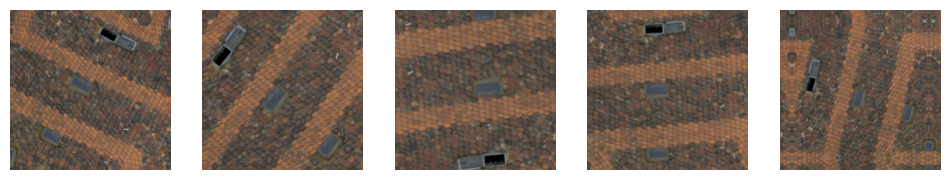

In [ ]:
import matplotlib.pyplot as plt

# Load one sample image from processed dataset
sample_path = df.iloc[0]["image_path"]
img = tf.io.read_file(sample_path)
img = tf.image.decode_png(img, channels=3)
img = tf.image.resize(img, (256, 256))

# Apply augmentations multiple times
plt.figure(figsize=(12,6))
for i in range(5):
    aug_img = data_augmentation(tf.expand_dims(img, 0))
    plt.subplot(1,5,i+1)
    plt.imshow(tf.cast(aug_img[0]*255, tf.uint8))
    plt.axis("off")
plt.show()


In [ ]:
import tensorflow as tf
import pandas as pd

# Paths (adjust if different)
OUT_ROOT = "/content/drive/MyDrive/CMFD_processed"
train_csv = pd.read_csv(f"{OUT_ROOT}/train.csv")
val_csv   = pd.read_csv(f"{OUT_ROOT}/val.csv")
test_csv  = pd.read_csv(f"{OUT_ROOT}/test.csv")

print("Train:", len(train_csv), "Val:", len(val_csv), "Test:", len(test_csv))

# ---- Step 3: Build TensorFlow Datasets ----

# Augmentation from Step 2
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal_and_vertical"),
    tf.keras.layers.RandomRotation(0.2),
    tf.keras.layers.RandomZoom(0.2),
    tf.keras.layers.RandomContrast(0.2),
    tf.keras.layers.Resizing(224, 224),   # for ViT/DINOv3 input
    tf.keras.layers.Rescaling(1./255)
])

# Simple preprocessing (no augmentation)
def preprocess_image(img_path, label, augment=False):
    img = tf.io.read_file(img_path)
    img = tf.image.decode_png(img, channels=3)
    img = tf.image.resize(img, (224,224))   # match DINOv3 input
    img = tf.cast(img, tf.float32) / 255.0
    if augment:
        img = data_augmentation(img, training=True)
    return img, label

def make_dataset(csv_df, augment=False, batch_size=32, shuffle=True):
    paths = csv_df["image_path"].values
    labels = csv_df["label"].values
    ds = tf.data.Dataset.from_tensor_slices((paths, labels))
    if shuffle:
        ds = ds.shuffle(buffer_size=len(csv_df))
    ds = ds.map(lambda x, y: preprocess_image(x, y, augment),
                num_parallel_calls=tf.data.AUTOTUNE)
    ds = ds.batch(batch_size).prefetch(tf.data.AUTOTUNE)
    return ds

# Create datasets
train_ds = make_dataset(train_csv, augment=True, batch_size=32, shuffle=True)
val_ds   = make_dataset(val_csv, augment=False, batch_size=32, shuffle=False)
test_ds  = make_dataset(test_csv, augment=False, batch_size=32, shuffle=False)

# Inspect one batch
for images, labels in train_ds.take(1):
    print("Batch images:", images.shape, "Batch labels:", labels.numpy())


Train: 3640 Val: 780 Test: 780
Batch images: (32, 224, 224, 3) Batch labels: [1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 0 1 1 1 1 1 1 1 1 1 0 1]


Train rows: 3640
Sampling patches from training set...


100%|██████████| 3640/3640 [01:01<00:00, 59.55it/s]


Collected pos: 30716 neg: 71830
Balancing: 30716 pos and 30716 neg patches
Converting positives...
Converting negatives...
Final balanced shapes: (30716, 64, 64, 3) (30716, 64, 64, 3)
✅ Saved balanced dataset -> /content/drive/MyDrive/CMFD_processed/gan_patches_balanced.npz Size MB: 854.2694673538208


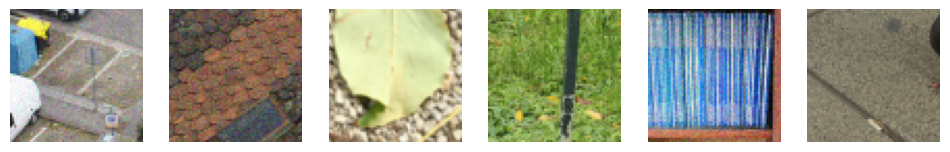

Step 4 finished: Balanced dataset ready for GAN training


In [ ]:
# Step 4 (memory-safe & balanced): Preprocess training data for GAN-based forgery generation
import os, random, cv2
from tqdm import tqdm
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ---------- USER CONFIG ----------
OUT_ROOT = "/content/drive/MyDrive/CMFD_processed"   # output root from Step1
TRAIN_CSV = os.path.join(OUT_ROOT, "train.csv")
PATCH_SIZE = 64         # generator output size in paper
STRIDE = 32             # stride for sliding window
POS_PER_IMAGE = 20      # positive patches per image
NEG_PER_IMAGE = 20      # negative patches per image
NPZ_BAL  = os.path.join(OUT_ROOT, "gan_patches_balanced.npz")  # final saved dataset
CHUNK_SIZE = 2000       # how many patches to process per mini-batch
SEED = 42
# ---------------------------------

random.seed(SEED)
np.random.seed(SEED)

# Load train manifest
if not os.path.exists(TRAIN_CSV):
    raise FileNotFoundError(f"Train CSV not found: {TRAIN_CSV}")
train_df = pd.read_csv(TRAIN_CSV)
print("Train rows:", len(train_df))

# ---- Helper: sample patches from image ----
def sample_patches_for_image(img_path, mask_path, pos_k=POS_PER_IMAGE, neg_k=NEG_PER_IMAGE):
    img = cv2.imread(img_path, cv2.IMREAD_COLOR)
    if img is None:
        return {"pos": [], "neg": []}
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    mk = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
    if mk is None:
        return {"pos": [], "neg": []}
    if img.shape[:2] != mk.shape[:2]:
        mk = cv2.resize(mk, (img.shape[1], img.shape[0]), interpolation=cv2.INTER_NEAREST)
    h,w = img.shape[:2]
    if h < PATCH_SIZE or w < PATCH_SIZE:  # pad small images
        pad_h = max(0, PATCH_SIZE - h)
        pad_w = max(0, PATCH_SIZE - w)
        img = cv2.copyMakeBorder(img,0,pad_h,0,pad_w,cv2.BORDER_REFLECT)
        mk  = cv2.copyMakeBorder(mk,0,pad_h,0,pad_w,cv2.BORDER_CONSTANT,value=0)
        h,w = img.shape[:2]

    candidates = []
    for y in range(0, h - PATCH_SIZE + 1, STRIDE):
        for x in range(0, w - PATCH_SIZE + 1, STRIDE):
            mask_patch = mk[y:y+PATCH_SIZE, x:x+PATCH_SIZE]
            forged_ratio = (mask_patch > 0).sum() / (PATCH_SIZE*PATCH_SIZE)
            candidates.append(((x,y), forged_ratio))

    pos_cands = [c for c in candidates if c[1] >= 0.10]  # ≥10% forged
    neg_cands = [c for c in candidates if c[1] <= 0.01]  # ≤1% forged
    random.shuffle(pos_cands); random.shuffle(neg_cands)

    sampled = {"pos": [], "neg": []}
    for i in range(min(pos_k, len(pos_cands))):
        x,y = pos_cands[i][0]
        sampled["pos"].append(img[y:y+PATCH_SIZE, x:x+PATCH_SIZE])
    for i in range(min(neg_k, len(neg_cands))):
        x,y = neg_cands[i][0]
        sampled["neg"].append(img[y:y+PATCH_SIZE, x:x+PATCH_SIZE])
    return sampled

# ---- Collect patches ----
pos_patches, neg_patches = [], []
rows = train_df.to_dict(orient="records")
print("Sampling patches from training set...")
for r in tqdm(rows):
    img_p, mask_p = r["image_path"], r["mask_path"]
    if not (os.path.exists(img_p) and os.path.exists(mask_p)):
        continue
    s = sample_patches_for_image(img_p, mask_p)
    pos_patches.extend(s["pos"])
    neg_patches.extend(s["neg"])

print("Collected pos:", len(pos_patches), "neg:", len(neg_patches))

# ---- Balance classes ----
target = min(len(pos_patches), len(neg_patches))
print(f"Balancing: {target} pos and {target} neg patches")
random.shuffle(pos_patches)
random.shuffle(neg_patches)
pos_patches = pos_patches[:target]
neg_patches = neg_patches[:target]

# ---- Convert to numpy arrays in chunks ----
def preprocess_patch(p):
    p = cv2.resize(p, (PATCH_SIZE, PATCH_SIZE))
    return (p.astype(np.float32) / 127.5) - 1.0  # scale to [-1,1]

def convert_in_chunks(patches, chunk_size=CHUNK_SIZE):
    arrs = []
    for i in range(0, len(patches), chunk_size):
        chunk = patches[i:i+chunk_size]
        arr = np.stack([preprocess_patch(p) for p in chunk], axis=0)
        arrs.append(arr)
    return np.concatenate(arrs, axis=0)

print("Converting positives...")
pos_np = convert_in_chunks(pos_patches, CHUNK_SIZE)
print("Converting negatives...")
neg_np = convert_in_chunks(neg_patches, CHUNK_SIZE)

print("Final balanced shapes:", pos_np.shape, neg_np.shape)

# ---- Save final balanced dataset ----
np.savez_compressed(NPZ_BAL, pos=pos_np, neg=neg_np)
print("✅ Saved balanced dataset ->", NPZ_BAL, "Size MB:", os.path.getsize(NPZ_BAL)/1024/1024)

# ---- Quick visualization ----
plt.figure(figsize=(12,4))
for i in range(6):
    im = (pos_np[i] + 1.0) * 0.5  # back to [0,1]
    plt.subplot(1,6,i+1)
    plt.imshow(np.clip(im,0,1))
    plt.axis("off")
plt.show()

print("Step 4 finished: Balanced dataset ready for GAN training")


In [ ]:
# Step 5: DCGAN (Generator + Discriminator) + Training loop (Colab-ready)
import os, math, time
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers
import matplotlib.pyplot as plt

# ---------------- USER CONFIG ----------------
OUT_ROOT = "/content/drive/MyDrive/CMFD_processed"
BAL_NPZ = os.path.join(OUT_ROOT, "gan_patches_balanced.npz")  # produced in Step 4
CHECKPOINT_DIR = os.path.join(OUT_ROOT, "gan_checkpoints")
SAMPLES_DIR = os.path.join(OUT_ROOT, "gan_samples")
BATCH_SIZE = 64
latent_dim = 100
EPOCHS = 40                 # change to 100+ for better results
save_every = 5              # save sample images every N epochs
learning_rate = 2e-4
beta_1 = 0.5
# ---------------------------------------------

os.makedirs(CHECKPOINT_DIR, exist_ok=True)
os.makedirs(SAMPLES_DIR, exist_ok=True)

# ---- Load balanced dataset ----
print("Loading balanced dataset:", BAL_NPZ)
data = np.load(BAL_NPZ)
pos = data['pos']   # forged patches normalized to [-1,1]
neg = data['neg']   # authentic patches normalized to [-1,1]
# We'll use pos (forged) as "real" examples for GAN to learn forged patch distribution.
real_patches = pos.astype(np.float32)
print("real_patches shape:", real_patches.shape)

# Create tf.data dataset (shuffle, batch)
dataset = tf.data.Dataset.from_tensor_slices(real_patches)
dataset = dataset.shuffle(buffer_size=10000).batch(BATCH_SIZE, drop_remainder=True).prefetch(tf.data.AUTOTUNE)

# ---- Model definitions ----
# Generator: z -> 64x64x3 (tanh)
def make_generator(latent_dim=100):
    model = tf.keras.Sequential(name="Generator")
    model.add(layers.Input(shape=(latent_dim,)))

    # Project and reshape
    model.add(layers.Dense(4*4*1024, use_bias=False))
    model.add(layers.BatchNormalization())
    model.add(layers.ReLU())
    model.add(layers.Reshape((4,4,1024)))  # 4x4x1024

    # Upsample blocks
    model.add(layers.Conv2DTranspose(512, (5,5), strides=(2,2), padding='same', use_bias=False))  # 8x8
    model.add(layers.BatchNormalization())
    model.add(layers.ReLU())

    model.add(layers.Conv2DTranspose(256, (5,5), strides=(2,2), padding='same', use_bias=False))  # 16x16
    model.add(layers.BatchNormalization())
    model.add(layers.ReLU())

    model.add(layers.Conv2DTranspose(128, (5,5), strides=(2,2), padding='same', use_bias=False))  # 32x32
    model.add(layers.BatchNormalization())
    model.add(layers.ReLU())

    model.add(layers.Conv2DTranspose(64, (5,5), strides=(2,2), padding='same', use_bias=False))   # 64x64
    model.add(layers.BatchNormalization())
    model.add(layers.ReLU())

    # Output layer
    model.add(layers.Conv2D(3, (5,5), padding='same', activation='tanh'))  # [-1,1]
    return model

# Discriminator: 64x64x3 -> scalar (sigmoid)
def make_discriminator():
    model = tf.keras.Sequential(name="Discriminator")
    model.add(layers.Input(shape=(64,64,3)))

    model.add(layers.Conv2D(64, (5,5), strides=(2,2), padding='same'))
    model.add(layers.LeakyReLU(0.2))
    model.add(layers.Dropout(0.3))

    model.add(layers.Conv2D(128, (5,5), strides=(2,2), padding='same'))
    model.add(layers.LeakyReLU(0.2))
    model.add(layers.Dropout(0.3))

    model.add(layers.Conv2D(256, (5,5), strides=(2,2), padding='same'))
    model.add(layers.LeakyReLU(0.2))
    model.add(layers.Dropout(0.3))

    model.add(layers.Conv2D(512, (5,5), strides=(2,2), padding='same'))
    model.add(layers.LeakyReLU(0.2))
    model.add(layers.Dropout(0.3))

    model.add(layers.Flatten())
    model.add(layers.Dense(1))  # logits
    return model

generator = make_generator(latent_dim)
discriminator = make_discriminator()
generator.summary()
discriminator.summary()

# ---- Losses and optimizers ----
cross_entropy = tf.keras.losses.BinaryCrossentropy(from_logits=True)

def discriminator_loss(real_logits, fake_logits):
    real_loss = cross_entropy(tf.ones_like(real_logits), real_logits)
    fake_loss = cross_entropy(tf.zeros_like(fake_logits), fake_logits)
    return real_loss + fake_loss

def generator_loss(fake_logits):
    return cross_entropy(tf.ones_like(fake_logits), fake_logits)

g_optimizer = tf.keras.optimizers.Adam(learning_rate, beta_1=beta_1)
d_optimizer = tf.keras.optimizers.Adam(learning_rate, beta_1=beta_1)

# ---- Checkpointing ----
checkpoint = tf.train.Checkpoint(generator=generator,
                                 discriminator=discriminator,
                                 g_optimizer=g_optimizer,
                                 d_optimizer=d_optimizer)
ckpt_mgr = tf.train.CheckpointManager(checkpoint, CHECKPOINT_DIR, max_to_keep=5)

# ---- Helper: save generated grid ----
def save_image_grid(images, path, grid_size=(6,6), to_uint8=True):
    # images: numpy array (N, H, W, C) in [-1,1]
    H, W = images.shape[1], images.shape[2]
    rows, cols = grid_size
    fig = plt.figure(figsize=(cols, rows))
    for i in range(rows*cols):
        if i >= images.shape[0]:
            break
        plt.subplot(rows, cols, i+1)
        im = (images[i] + 1.0) * 0.5
        plt.imshow(np.clip(im,0,1))
        plt.axis('off')
    plt.tight_layout()
    fig.savefig(path, dpi=150)
    plt.close(fig)

# ---- Training step (tf.function for speed) ----
@tf.function
def train_step(real_images):
    batch_size = tf.shape(real_images)[0]
    noise = tf.random.normal([batch_size, latent_dim])

    # Train discriminator
    with tf.GradientTape() as d_tape:
        fake_images = generator(noise, training=True)
        real_logits = discriminator(real_images, training=True)
        fake_logits = discriminator(fake_images, training=True)
        d_loss = discriminator_loss(real_logits, fake_logits)
    d_grad = d_tape.gradient(d_loss, discriminator.trainable_variables)
    d_optimizer.apply_gradients(zip(d_grad, discriminator.trainable_variables))

    # Train generator
    noise = tf.random.normal([batch_size, latent_dim])
    with tf.GradientTape() as g_tape:
        fake_images = generator(noise, training=True)
        fake_logits = discriminator(fake_images, training=True)
        g_loss = generator_loss(fake_logits)
    g_grad = g_tape.gradient(g_loss, generator.trainable_variables)
    g_optimizer.apply_gradients(zip(g_grad, generator.trainable_variables))

    return d_loss, g_loss

# ---- Training loop ----
seed = tf.random.normal([36, latent_dim])  # fixed seed for sample grids (6x6)
start_epoch = 0
if ckpt_mgr.latest_checkpoint:
    print("Restoring from", ckpt_mgr.latest_checkpoint)
    checkpoint.restore(ckpt_mgr.latest_checkpoint)
    # Could parse saved epoch if you saved it separately

print("Starting training for", EPOCHS, "epochs. This may take time depending on GPU.")
hist = {"d_loss": [], "g_loss": []}
t0 = time.time()
for epoch in range(start_epoch, EPOCHS):
    t_ep = time.time()
    d_losses = []
    g_losses = []
    for batch_idx, real_batch in enumerate(dataset):
        d_loss, g_loss = train_step(real_batch)
        d_losses.append(d_loss.numpy())
        g_losses.append(g_loss.numpy())

    d_epoch = float(np.mean(d_losses))
    g_epoch = float(np.mean(g_losses))
    hist["d_loss"].append(d_epoch)
    hist["g_loss"].append(g_epoch)

    # save checkpoints
    ckpt_mgr.save()

    # generate samples for monitoring
    gen_images = generator(seed, training=False).numpy()  # shape (36,64,64,3)
    sample_path = os.path.join(SAMPLES_DIR, f"epoch_{epoch+1:03d}.png")
    save_image_grid(gen_images, sample_path, grid_size=(6,6))
    elapsed = time.time() - t_ep
    print(f"Epoch {epoch+1:03d}/{EPOCHS}  d_loss={d_epoch:.4f}  g_loss={g_epoch:.4f}  time={elapsed:.1f}s  saved->{sample_path}")

print("Training finished. Total time:", time.time()-t0, "s")

# ---- Quick plot of losses ----
plt.figure(figsize=(8,4))
plt.plot(hist["d_loss"], label='d_loss')
plt.plot(hist["g_loss"], label='g_loss')
plt.legend()
plt.title("GAN losses")
plt.show()

# ---- Show last sample grid inline ----
from IPython.display import Image, display
display(Image(filename=sample_path))


Loading balanced dataset: /content/drive/MyDrive/CMFD_processed/gan_patches_balanced.npz
real_patches shape: (30716, 64, 64, 3)


Model: "Generator"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 16384)          │     1,638,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 16384)          │        65,536 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu (ReLU)                    │ (None, 16384)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape (Reshape)               │ (None, 4, 4, 1024)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose                │ (None, 8, 8, 512)      │    13,107,200 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 8, 8, 512)      │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_1 (ReLU)                  │ (None, 8, 8, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_1              │ (None, 16, 16, 256)    │     3,276,800 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 16, 16, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_2 (ReLU)                  │ (None, 16, 16, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_2              │ (None, 32, 32, 128)    │       819,200 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 32, 32, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_3 (ReLU)                  │ (None, 32, 32, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_3              │ (None, 64, 64, 64)     │       204,800 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 64, 64, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_4 (ReLU)                  │ (None, 64, 64, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 64, 64, 3)      │         4,803 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 19,120,579 (72.94 MB)

 Trainable params: 19,085,891 (72.81 MB)

...

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_1 (Conv2D)               │ (None, 32, 32, 64)     │         4,864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu (LeakyReLU)         │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 16, 16, 128)    │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_1 (LeakyReLU)       │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 8, 8, 256)      │       819,456 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_2 (LeakyReLU)       │ (None, 8, 8, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 8, 8, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 4, 4, 512)      │     3,277,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_3 (LeakyReLU)       │ (None, 4, 4, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 4, 4, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 8192)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │         8,193 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,314,753 (16.46 MB)

 Trainable params: 4,314,753 (16.46 MB)

 Non-trainable params: 0 (0.00 B)

Starting training for 40 epochs. This may take time depending on GPU.
Epoch 001/40  d_loss=1.1066  g_loss=1.9715  time=222.2s  saved->/content/drive/MyDrive/CMFD_processed/gan_samples/epoch_001.png
Epoch 002/40  d_loss=1.1695  g_loss=1.3125  time=211.6s  saved->/content/drive/MyDrive/CMFD_processed/gan_samples/epoch_002.png
Epoch 003/40  d_loss=1.0495  g_loss=1.5011  time=214.3s  saved->/content/drive/MyDrive/CMFD_processed/gan_samples/epoch_003.png
Epoch 004/40  d_loss=1.0079  g_loss=1.5901  time=215.2s  saved->/content/drive/MyDrive/CMFD_processed/gan_samples/epoch_004.png
Epoch 005/40  d_loss=0.9408  g_loss=1.5983  time=212.5s  saved->/content/drive/MyDrive/CMFD_processed/gan_samples/epoch_005.png
Epoch 006/40  d_loss=0.7916  g_loss=1.9607  time=213.9s  saved->/content/drive/MyDrive/CMFD_processed/gan_samples/epoch_006.png
Epoch 007/40  d_loss=0.6728  g_loss=2.3178  time=216.2s  saved->/content/drive/MyDrive/CMFD_processed/gan_samples/epoch_007.png
Epoch 008/40  d_loss=0.5632  g_los

In [ ]:
# --- Resume GAN Training from Checkpoint ---
import os, numpy as np, tensorflow as tf
from tensorflow.keras import layers
import matplotlib.pyplot as plt

# ---------------- CONFIG ----------------
OUT_ROOT = "/content/drive/MyDrive/CMFD_processed"
CHECKPOINT_DIR = os.path.join(OUT_ROOT, "gan_checkpoints")
SAMPLES_DIR = os.path.join(OUT_ROOT, "gan_samples")
latent_dim = 100
EPOCHS = 40
BATCH_SIZE = 64
learning_rate = 2e-4
beta_1 = 0.5
# ----------------------------------------

os.makedirs(SAMPLES_DIR, exist_ok=True)

# --- Rebuild models ---
def make_generator(latent_dim=100):
    model = tf.keras.Sequential([
        layers.Input(shape=(latent_dim,)),
        layers.Dense(4*4*1024, use_bias=False),
        layers.BatchNormalization(),
        layers.ReLU(),
        layers.Reshape((4,4,1024)),
        layers.Conv2DTranspose(512, (5,5), strides=2, padding="same", use_bias=False),
        layers.BatchNormalization(),
        layers.ReLU(),
        layers.Conv2DTranspose(256, (5,5), strides=2, padding="same", use_bias=False),
        layers.BatchNormalization(),
        layers.ReLU(),
        layers.Conv2DTranspose(128, (5,5), strides=2, padding="same", use_bias=False),
        layers.BatchNormalization(),
        layers.ReLU(),
        layers.Conv2DTranspose(64, (5,5), strides=2, padding="same", use_bias=False),
        layers.BatchNormalization(),
        layers.ReLU(),
        layers.Conv2D(3, (5,5), padding="same", activation="tanh")
    ], name="Generator")
    return model

def make_discriminator():
    model = tf.keras.Sequential([
        layers.Input(shape=(64,64,3)),
        layers.Conv2D(64, (5,5), strides=2, padding="same"), layers.LeakyReLU(0.2), layers.Dropout(0.3),
        layers.Conv2D(128, (5,5), strides=2, padding="same"), layers.LeakyReLU(0.2), layers.Dropout(0.3),
        layers.Conv2D(256, (5,5), strides=2, padding="same"), layers.LeakyReLU(0.2), layers.Dropout(0.3),
        layers.Conv2D(512, (5,5), strides=2, padding="same"), layers.LeakyReLU(0.2), layers.Dropout(0.3),
        layers.Flatten(),
        layers.Dense(1)
    ], name="Discriminator")
    return model

generator = make_generator(latent_dim)
discriminator = make_discriminator()

# --- Losses & optimizers ---
cross_entropy = tf.keras.losses.BinaryCrossentropy(from_logits=True)

def d_loss_fn(real_logits, fake_logits):
    real_loss = cross_entropy(tf.ones_like(real_logits), real_logits)
    fake_loss = cross_entropy(tf.zeros_like(fake_logits), fake_logits)
    return real_loss + fake_loss

def g_loss_fn(fake_logits):
    return cross_entropy(tf.ones_like(fake_logits), fake_logits)

g_optimizer = tf.keras.optimizers.Adam(learning_rate, beta_1=beta_1)
d_optimizer = tf.keras.optimizers.Adam(learning_rate, beta_1=beta_1)

# --- Train step ---
@tf.function
def train_step(real_images):
    batch_size = tf.shape(real_images)[0]
    noise = tf.random.normal([batch_size, latent_dim])

    # Train discriminator
    with tf.GradientTape() as d_tape:
        fake_images = generator(noise, training=True)
        real_logits = discriminator(real_images, training=True)
        fake_logits = discriminator(fake_images, training=True)
        d_loss = d_loss_fn(real_logits, fake_logits)
    d_grad = d_tape.gradient(d_loss, discriminator.trainable_variables)
    d_optimizer.apply_gradients(zip(d_grad, discriminator.trainable_variables))

    # Train generator
    noise = tf.random.normal([batch_size, latent_dim])
    with tf.GradientTape() as g_tape:
        fake_images = generator(noise, training=True)
        fake_logits = discriminator(fake_images, training=True)
        g_loss = g_loss_fn(fake_logits)
    g_grad = g_tape.gradient(g_loss, generator.trainable_variables)
    g_optimizer.apply_gradients(zip(g_grad, generator.trainable_variables))

    return d_loss, g_loss

# --- Checkpoint with epoch tracker ---
last_epoch = tf.Variable(0, dtype=tf.int64)
checkpoint = tf.train.Checkpoint(generator=generator,
                                 discriminator=discriminator,
                                 g_optimizer=g_optimizer,
                                 d_optimizer=d_optimizer,
                                 last_epoch=last_epoch)
ckpt_mgr = tf.train.CheckpointManager(checkpoint, CHECKPOINT_DIR, max_to_keep=5)

# --- Restore ---
start_epoch = 0
if ckpt_mgr.latest_checkpoint:
    checkpoint.restore(ckpt_mgr.latest_checkpoint).expect_partial()
    start_epoch = int(last_epoch.numpy())
    print(f"✅ Restored from {ckpt_mgr.latest_checkpoint}, resuming at epoch {start_epoch+1}")
else:
    print("⚡ No checkpoint found. Starting fresh.")

# --- Reload dataset ---
BAL_NPZ = os.path.join(OUT_ROOT, "gan_patches_balanced.npz")
print("Loading dataset:", BAL_NPZ)
data = np.load(BAL_NPZ)
real_patches = data["pos"].astype(np.float32)
dataset = tf.data.Dataset.from_tensor_slices(real_patches).shuffle(10000).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

# --- Sample save helper ---
def save_image_grid(images, path, grid_size=(6,6)):
    import matplotlib.pyplot as plt
    rows, cols = grid_size
    fig, axs = plt.subplots(rows, cols, figsize=(cols, rows))
    for i, ax in enumerate(axs.flatten()):
        if i >= images.shape[0]:
            break
        im = (images[i] + 1.0) * 0.5
        ax.imshow(np.clip(im,0,1))
        ax.axis("off")
    plt.tight_layout()
    plt.savefig(path, dpi=150)
    plt.close(fig)

# --- Training loop ---
seed = tf.random.normal([36, latent_dim])
for epoch in range(start_epoch, EPOCHS):
    d_losses, g_losses = [], []
    for real_batch in dataset:
        d_loss, g_loss = train_step(real_batch)
        d_losses.append(d_loss.numpy())
        g_losses.append(g_loss.numpy())

    last_epoch.assign(epoch + 1)  # update epoch
    ckpt_mgr.save()

    gen_images = generator(seed, training=False).numpy()
    sample_path = os.path.join(SAMPLES_DIR, f"epoch_{epoch+1:03d}.png")
    save_image_grid(gen_images, sample_path)

    print(f"Epoch {epoch+1}/{EPOCHS} d_loss={np.mean(d_losses):.4f} g_loss={np.mean(g_losses):.4f} saved->{sample_path}")

print("✅ Training finished")


✅ Restored from /content/drive/MyDrive/CMFD_processed/gan_checkpoints/ckpt-11, resuming at epoch 1
Loading dataset: /content/drive/MyDrive/CMFD_processed/gan_patches_balanced.npz
Epoch 1/40 d_loss=0.3132 g_loss=3.8862 saved->/content/drive/MyDrive/CMFD_processed/gan_samples/epoch_001.png
Epoch 2/40 d_loss=0.2713 g_loss=4.1701 saved->/content/drive/MyDrive/CMFD_processed/gan_samples/epoch_002.png
Epoch 3/40 d_loss=0.2242 g_loss=4.6434 saved->/content/drive/MyDrive/CMFD_processed/gan_samples/epoch_003.png
Epoch 4/40 d_loss=0.2055 g_loss=4.9908 saved->/content/drive/MyDrive/CMFD_processed/gan_samples/epoch_004.png
Epoch 5/40 d_loss=0.1781 g_loss=5.0861 saved->/content/drive/MyDrive/CMFD_processed/gan_samples/epoch_005.png
Epoch 6/40 d_loss=0.2395 g_loss=5.3214 saved->/content/drive/MyDrive/CMFD_processed/gan_samples/epoch_006.png
Epoch 7/40 d_loss=0.1904 g_loss=5.3716 saved->/content/drive/MyDrive/CMFD_processed/gan_samples/epoch_007.png
Epoch 8/40 d_loss=0.1653 g_loss=5.5387 saved->/cont